# Stock Price Predcition - Baseline model

I'll only use the numerical data for a baseline model, testing a linear and non-linear one.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

## 1. Data loading & target definition

**Target**: next-day close price (`close_t+1`), created by shifting close by -1. The email did not specify the target variable so I'm assuming this.

In [2]:
price_df = pd.read_csv('data/price.csv', parse_dates=['date'])
price_df = price_df.sort_values(['ticker', 'date']).reset_index(drop=True)

# target: next-day close
price_df['target'] = price_df.groupby('ticker')['close'].shift(-1)

print(f"Rows: {len(price_df):,}")
print(f"Tickers: {sorted(price_df['ticker'].unique())}")
print(f"Date range: {price_df['date'].min().date()} → {price_df['date'].max().date()}")
price_df.head()

Rows: 1,687
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Date range: 2023-11-13 → 2024-10-28


,date,ticker,open,high,low,close,volume,target
0,2023-11-13,AAPL,185.820007,186.029999,184.210007,184.800003,43627500,187.440002
1,2023-11-14,AAPL,187.699997,188.110001,186.300003,187.440002,60108400,188.009995
2,2023-11-15,AAPL,187.850006,189.500000,187.779999,188.009995,53790500,189.710007
3,2023-11-16,AAPL,189.570007,190.960007,188.649994,189.710007,54412900,189.690002
4,2023-11-17,AAPL,190.250000,190.380005,188.570007,189.690002,50922700,191.449997


## 2. Feature engineering

### Multicollinearity
In the EDA, I found severe multicollinearity among raw daily prices. I was not familiar with stock prices, from what I found in different sources this are some procedures to avoid the redundancy caused by multicolinearity.

1. Feature Exclusion: Exclude the highly correlated raw features.

2. Stationary & Relative Transformations: We convert raw prices into non-collinear features: stationarized returns (`daily_return`, `return_5d`), ratios (`close_to_sma20`, `volume_ratio_5`), and bounded oscillators (`rsi_14`).

3. L2 Regularization: For features that still overlap (like recent price history or overlapping averages), let's use Ridge Regression (a method that adds a penalty to keep coefficients small) instead of standard regression to keep the model stable.

Technical Indicators

**Lag prices** (`close_lag_1..5`): Looking at recent past prices to help predict what happens next.

**Moving averages** (`sma_5/10/20`): A smoothed average of prices over 5, 10, or 20 periods to spot the general trend direction.

**Volatility** (`rolling_std_5/10`): Measures how wildly prices swing around; higher volatility usually means harder-to-predict movements.

**Momentum** (`daily_return`, `return_5d`, `rsi_14`): Tracks how fast and in what direction prices are moving.

**Volume** (`volume_ratio_5`): Compares current trading activity to recent averages to spot unusual spikes that might signal a breakout.

**Mean reversion** (`close_to_sma20`): Measures how far the price has stretched away from its average, since overextended prices tend to snap back.

**Calendar** (`day_of_week`): Captures any recurring patterns based on the day of the week.

In [4]:
def engineer_features(df):
    """Create technical features per ticker."""
    df = df.copy()
    
    for ticker in df['ticker'].unique():
        mask = df['ticker'] == ticker
        ticker_data = df.loc[mask].copy()
        
        # lag features (1-5 days)
        for lag in range(1, 6):
            df.loc[mask, f'close_lag_{lag}'] = ticker_data['close'].shift(lag)
        
        # simple moving averages
        for window in [5, 10, 20]:
            df.loc[mask, f'sma_{window}'] = ticker_data['close'].rolling(window).mean()
        
        # volatility (rolling std of daily returns)
        daily_ret = ticker_data['close'].pct_change()
        for window in [5, 10]:
            df.loc[mask, f'rolling_std_{window}'] = daily_ret.rolling(window).std()
        
        # momentum
        df.loc[mask, 'daily_return'] = daily_ret
        df.loc[mask, 'return_5d'] = ticker_data['close'].pct_change(5)
        
        # RSI (14-day)
        delta = ticker_data['close'].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        rs = gain / loss
        df.loc[mask, 'rsi_14'] = 100 - (100 / (1 + rs))
        
        # volume ratio vs 5-day average
        df.loc[mask, 'volume_ratio_5'] = (
            ticker_data['volume'] / ticker_data['volume'].rolling(5).mean()
        )
        
        # close relative to SMA20 (mean reversion signal)
        sma20 = ticker_data['close'].rolling(20).mean()
        df.loc[mask, 'close_to_sma20'] = ticker_data['close'] / sma20
    
    # calendar feature
    df['day_of_week'] = df['date'].dt.dayofweek
    
    return df


price_df = engineer_features(price_df)
print(f"Features created: {price_df.shape[1]} columns")
price_df.head()

Features created: 24 columns


,date,ticker,open,high,low,close,volume,target,close_lag_1,close_lag_2,...,sma_10,sma_20,rolling_std_5,rolling_std_10,daily_return,return_5d,rsi_14,volume_ratio_5,close_to_sma20,day_of_week
0,2023-11-13,AAPL,185.820007,186.029999,184.210007,184.800003,43627500,187.440002,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2023-11-14,AAPL,187.699997,188.110001,186.300003,187.440002,60108400,188.009995,184.800003,NaN,...,NaN,NaN,NaN,NaN,0.014286,NaN,NaN,NaN,NaN,1
2,2023-11-15,AAPL,187.850006,189.500000,187.779999,188.009995,53790500,189.710007,187.440002,184.800003,...,NaN,NaN,NaN,NaN,0.003041,NaN,NaN,NaN,NaN,2
3,2023-11-16,AAPL,189.570007,190.960007,188.649994,189.710007,54412900,189.690002,188.009995,187.440002,...,NaN,NaN,NaN,NaN,0.009042,NaN,NaN,NaN,NaN,3
4,2023-11-17,AAPL,190.250000,190.380005,188.570007,189.690002,50922700,191.449997,189.710007,188.009995,...,NaN,NaN,NaN,NaN,-0.000105,NaN,NaN,0.96862,NaN,4


## 3. Train / test split

Time-based split, I'm familiar with this for time series in general.

~80% train (through Jul 2024) / ~20% test (Aug–Oct 2024).

In [5]:
# define feature columns (exclude identifiers & target)
exclude_cols = ['date', 'ticker', 'target', 'open', 'high', 'low', 'close', 'volume']
feature_cols = [c for c in price_df.columns if c not in exclude_cols]

# drop rows with NaN (from lag/rolling features + last row per ticker with no target)
model_df = price_df.dropna(subset=feature_cols + ['target']).copy()

# time-based split
split_date = pd.Timestamp('2024-08-01')
train_df = model_df[model_df['date'] < split_date]
test_df = model_df[model_df['date'] >= split_date]

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(train_df):,} rows ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f"\nFeature list: {feature_cols}")
X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

Features: 16
Train: 1,120 rows (2023-12-11 → 2024-07-31)
Test:  427 rows (2024-08-01 → 2024-10-25)

Feature list: ['close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_4', 'close_lag_5', 'sma_5', 'sma_10', 'sma_20', 'rolling_std_5', 'rolling_std_10', 'daily_return', 'return_5d', 'rsi_14', 'volume_ratio_5', 'close_to_sma20', 'day_of_week']


## 4. Model 1: Ridge regression

**Why?** I need to know if the price signal is fundamentally linear. Stock prices are highly autocorrelated. Today's price is the strongest predictor of tomorrow's. The implementation of a non linear one needs to justify itself by being better than this one.

Ridge (L2 regularization) is preferred over plain OLS to prevent coefficient inflation from correlated features (the lag/SMA features are inherently correlated).

In [6]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute and display regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"{'─' * 40}")
    print(f"{model_name}")
    print(f"{'─' * 40}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  R²:    {r2:.4f}")
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

In [11]:
# ridge regression needs scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

ridge_metrics = evaluate_model(y_test, ridge_pred, 'Ridge Regression')

────────────────────────────────────────
Ridge Regression
────────────────────────────────────────
  RMSE:  6.3003
  MAE:   4.2625
  MAPE:  1.85%
  R²:    0.9981


## 5. Model 2: XGBoost

**Why?** Maybe non-linear patterns (e.g., interactions between volatility and momentum, or regime-dependent behavior) add predictive power. XGBoost is the standard choice for tabular regression:
- Handles feature interactions and non-linearities natively through decision tree splits
- Built-in regularization (max_depth, subsample, L1/L2) to control overfitting
- Consistently top-performing on structured data benchmarks (Kaggle, academic literature)

In [14]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_metrics = evaluate_model(y_test, xgb_pred, 'XGBoost')

────────────────────────────────────────
XGBoost
────────────────────────────────────────
  RMSE:  19.8317
  MAE:   9.6293
  MAPE:  2.97%
  R²:    0.9810


actually worse results

# 6. Evaluation

## 6.1 Model comparison

In [15]:
results_df = pd.DataFrame([ridge_metrics, xgb_metrics]).set_index('model')
results_df.style.format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%', 'R2': '{:.4f}'})

,RMSE,MAE,MAPE,R2
model,,,,
Ridge Regression,6.3003,4.2625,1.85%,0.9981
XGBoost,19.8317,9.6293,2.97%,0.9810


## 6.2 Predicted vs actual (per ticker)

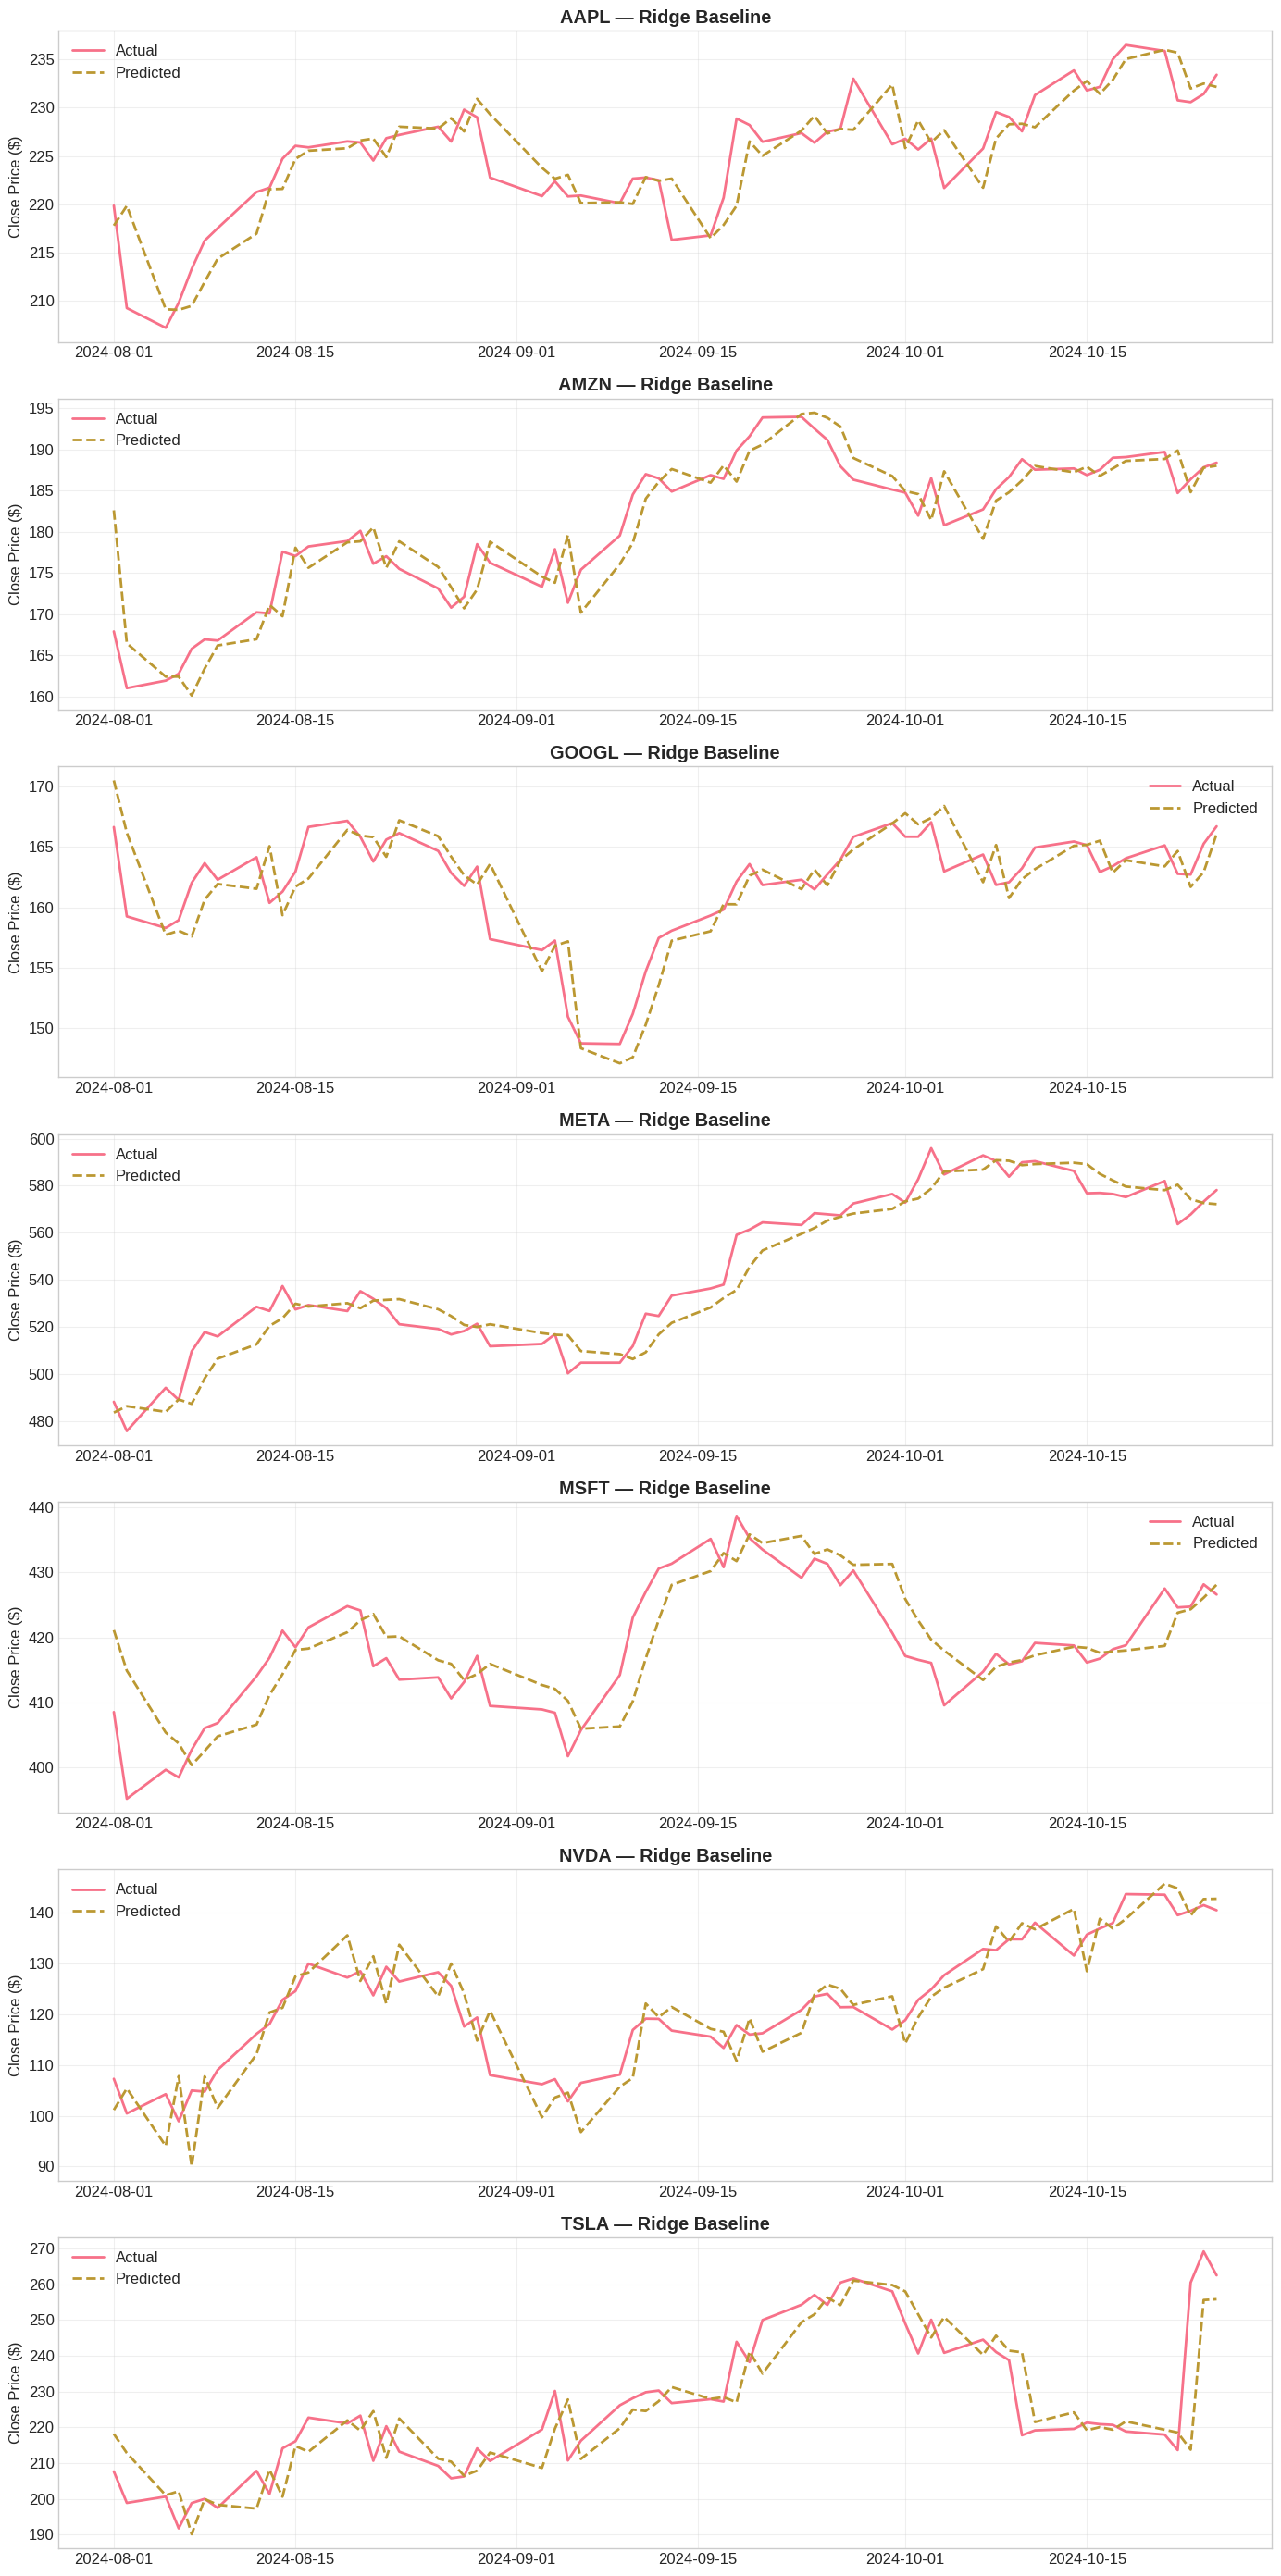

In [16]:
# use the best model for plotting
best_pred = xgb_pred if xgb_metrics['RMSE'] < ridge_metrics['RMSE'] else ridge_pred
best_name = 'XGBoost' if xgb_metrics['RMSE'] < ridge_metrics['RMSE'] else 'Ridge'

test_plot = test_df[['date', 'ticker', 'target']].copy()
test_plot['predicted'] = best_pred

tickers = sorted(test_plot['ticker'].unique())
fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4 * len(tickers)), sharex=False)

for i, ticker in enumerate(tickers):
    ax = axes[i]
    t = test_plot[test_plot['ticker'] == ticker]
    ax.plot(t['date'], t['target'], label='Actual', linewidth=2)
    ax.plot(t['date'], t['predicted'], label='Predicted', linewidth=2, linestyle='--')
    ax.set_title(f'{ticker} — {best_name} Baseline', fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ridge best overall

## 6.3 XGBoost feature importance

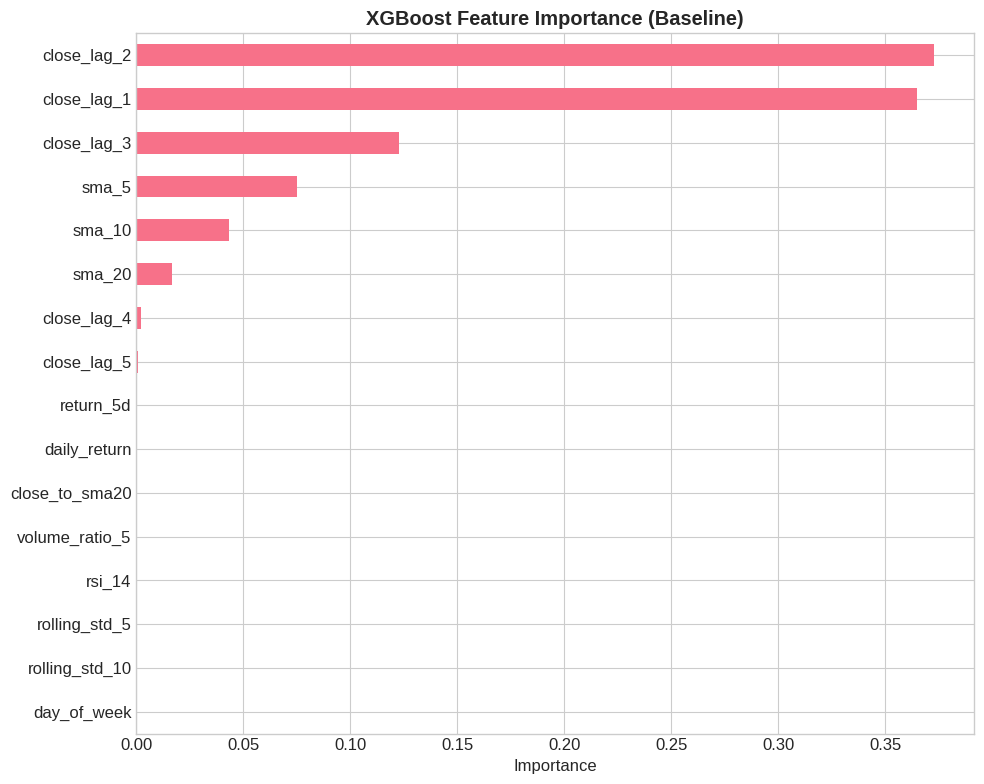

In [17]:
importance = pd.Series(
    xgb_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax)
ax.set_title('XGBoost Feature Importance (Baseline)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


# 7. Final remarks

- Ridge outperforms: coincides with the linear models I saw implemented in literature. XGBoost overfits.
- Lag features were the most important.
- Low Mean Absolute Percentage Error.

**Next**: add the news data and try another tree based model.

In [18]:
# save baseline results and features for use in notebook 03
model_df.to_csv('output/price_features.csv', index=False)
results_df.to_csv('output/baseline_results.csv')
print("Saved: output/price_features.csv, output/baseline_results.csv")

Saved: output/price_features.csv, output/baseline_results.csv
